# NAE optimization
This file sees how far we can push pyAQSC's aspect ratio

In [1]:
import importlib
import aqsc
import time
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
jax.config.update("jax_compilation_cache_dir", "/tmp/jax_cache")
jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)
jax.config.update("jax_persistent_cache_enable_xla_caches", "xla_gpu_per_fusion_autotune_cache_dir")
from shared import *


In [3]:
eq_test = solve_order_6(x_flat_init)

Default interpolation method: cubic
Solving for \bar{\iota}_0 self-consistently.
Evaluating order 3 4
Evaluating order 5 6


In [1]:
%%time
eq_test.get_psi_crit_legacy()

CPU times: user 5 μs, sys: 1 μs, total: 6 μs
Wall time: 8.58 μs


NameError: name 'eq_test' is not defined

In [2]:
population = jnp.load('population.npy')
fitness = jnp.load('fitness.npy')
argsort_fitness = jnp.argsort(fitness)
sorted_population = population[argsort_fitness]
sorted_fitness = fitness[argsort_fitness]

Default interpolation method: cubic
Solving for \bar{\iota}_0 self-consistently.
Evaluating order 3 4
Evaluating order 5 6
Δ:   2.9524e-02     R/r:   8.6856e+00     ι0:  -1.2492e+00     p_axis-p_edge (estimate):          nan     


/scratch/miniconda3/envs/desc/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/scratch/miniconda3/envs/desc/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Δ:   7.4041e-02     R/r:   1.8346e+01     ι0:  -1.2510e+00     p_axis-p_edge (estimate):          nan     
Δ:   5.0493e-02     R/r:   2.9666e+01     ι0:  -1.2576e+00     p_axis-p_edge (estimate):          nan     
Δ:   7.6052e-02     R/r:   2.6709e+01     ι0:  -1.2520e+00     p_axis-p_edge (estimate):          nan     
Δ:   1.0088e-01     R/r:   1.5072e+01     ι0:  -1.2491e+00     p_axis-p_edge (estimate):          nan     
Δ:   6.4821e-02     R/r:   3.4522e+01     ι0:  -1.2559e+00     p_axis-p_edge (estimate):          nan     
Δ:   7.6751e-02     R/r:   3.4249e+01     ι0:  -1.2533e+00     p_axis-p_edge (estimate):          nan     
Δ:   8.7147e-02     R/r:   3.1624e+01     ι0:  -1.2414e+00     p_axis-p_edge (estimate):  -1.9295e+14     
Δ:          nan     R/r:          nan     ι0:          nan     p_axis-p_edge (estimate):          nan     
Δ:   9.2080e-02     R/r:   3.0412e+01     ι0:  -1.2389e+00     p_axis-p_edge (estimate):  -2.0155e+14     
Δ:   9.6661e-02     R/r:   2.9318e+01

KeyboardInterrupt: 

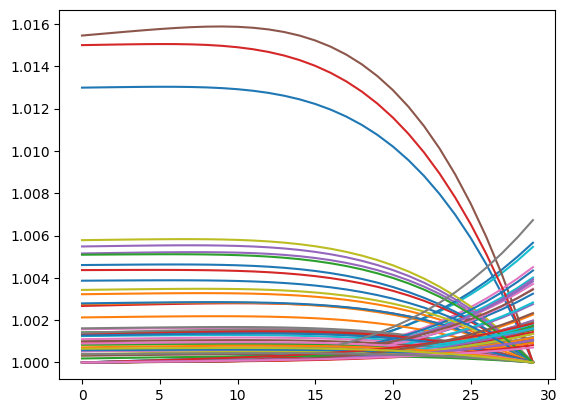

In [3]:
for i in range(len(sorted_fitness)):
    if sorted_fitness[i]:
        eq_fin = solve_order_6(jnp.array(sorted_population[i]), padded=True, m=10)
        fin_anisotropy = rms_anisotropy(eq_fin)
        fin_aspect = aspect_conv(eq_fin)
        fin_eps_conv = eps_conv(eq_fin)
        fin_iota = iota_axis(eq_fin)
        p_edge_eff = p_rms_vol(eq_fin, 1.00, 0.99)
        p_axis_eff = p_rms_vol(eq_fin, 0.01, 0.)
        print(
            'Δ:', f'{fin_anisotropy:>12.4e}', '    '
            'R/r:', f'{fin_aspect:>12.4e}', '    '
            'ι0:', f'{fin_iota:>12.4e}', '    '
            'p_axis-p_edge (estimate):', f'{p_axis_eff - p_edge_eff:>12.4e}', '    '
        )
        pres_profile = eq_fin.p_perp.eval_eps(jnp.linspace(0, fin_eps_conv, 30), 0, 0)
        plt.plot(pres_profile/jnp.max(pres_profile))
        if fin_anisotropy and fin_aspect and fin_iota:
            jnp.save('population_eq/eq'+str(i), eq_fin)

In [4]:
psi_crit, _, _ = eq_fin.get_psi_crit()

In [31]:
type(eq_fin.p_perp)

aqsc.chiphiepsfunc.ChiPhiEpsFunc

In [5]:
psi_crit

Array(3.98975514e-17+0.j, dtype=complex128)

(<Figure size 1280x960 with 1 Axes>, <Axes3D: >)

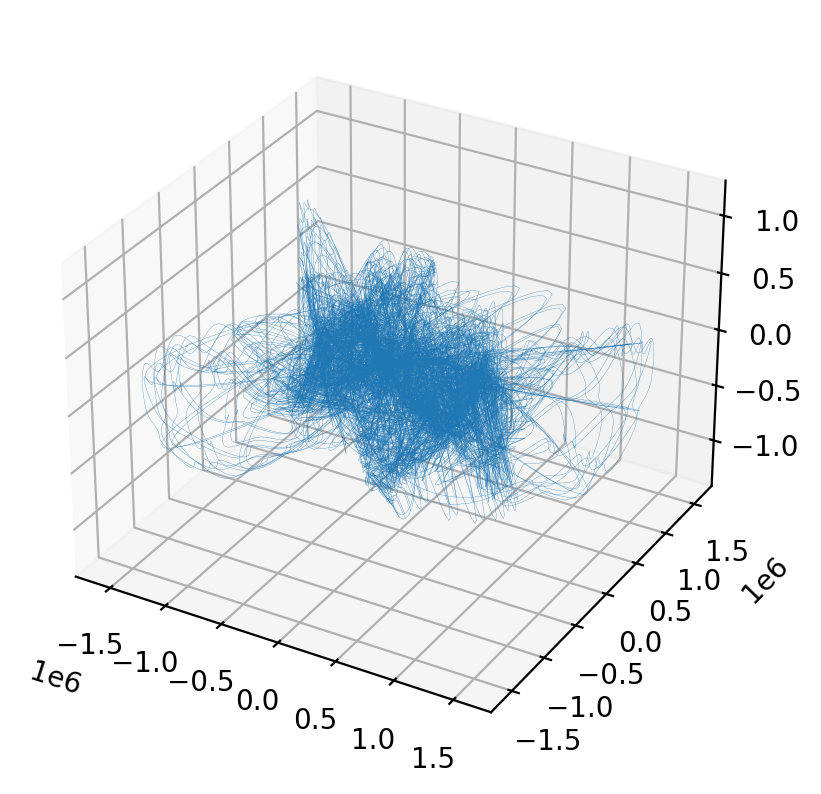

In [7]:
eq_fin.display_wireframe(eps_conv(eq_fin))

(<Figure size 1280x960 with 1 Axes>, <Axes3D: >)

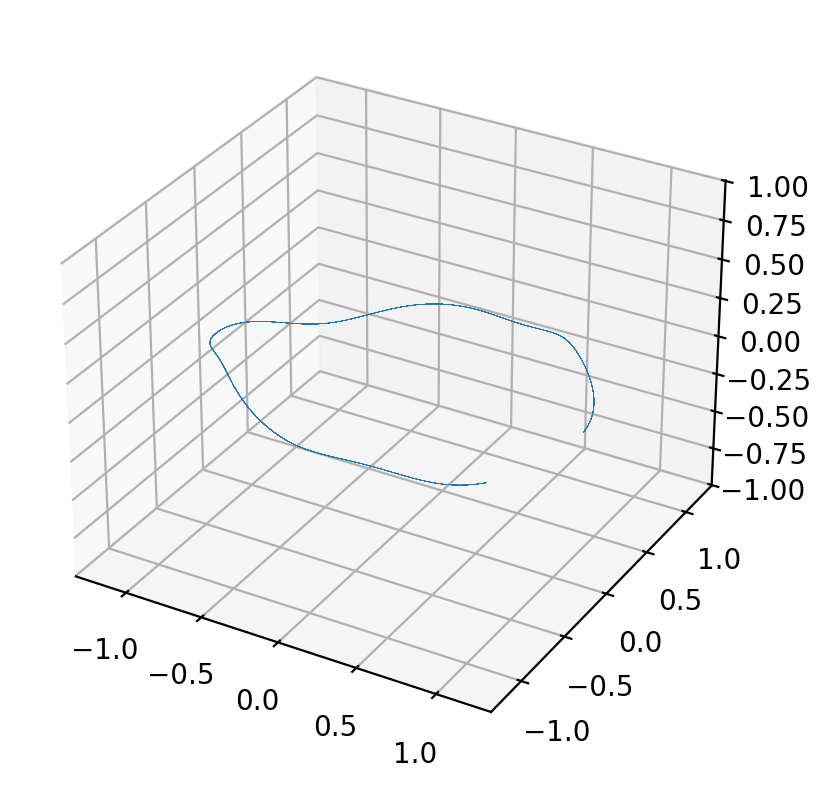

In [8]:
eq_fin.display_wireframe(jnp.sqrt(psi_crit))

In [ ]:
eq_fin.unknown['B_psi_coef_cp'][1].content

In [ ]:
objective(sorted_population[i], 1., 1., 1., 1., 2)

# Optimization

In [ ]:
import optimistix as optx
from scipy.optimize import minimize